In [26]:
import pandas as pd
import seaborn as sns

In [27]:
df_pib = pd.read_csv("data_2025/pib2020-2025.csv")
df_life = pd.read_csv("data_2025/WHO_life_expectancy.csv")

display(df_pib.sample(5))
display(df_life.sample(5))

df_life.rename(columns={"Location": "Country"}, inplace=True)

,Country,2020,2021,2022,2023,2024,2025
139,Portugal,229435,256226.0,257101.0,289781.0,308590.0,321440.0
75,Hungary,158468,183283.0,178321.0,214098.0,223060.0,237070.0
9,Australia,1362613,1655843.0,1725461.0,1742461.0,1796805.0,1771681.0
31,Cameroon,40863,45036.0,44442.0,49283.0,52784.0,56011.0
52,El Salvador,24921,29043.0,31989.0,34016.0,35337.0,36749.0


,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Location,Period type,Period,Dim1 type,Dim1,Value
2132,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,GBR,United Kingdom of Great Britain and Northern I...,Year,2020,Sex,Both sexes,23.1 [23.1-23.2]
7965,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,TKM,Turkmenistan,Year,2014,Sex,Both sexes,68.9 [68.5-69.3]
23059,WHOSIS_000015,Life expectancy at age 60 (years),SEAR,South-East Asia,Country,NPL,Nepal,Year,2001,Sex,Female,18.6 [18.3-19.0]
6344,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,ARG,Argentina,Year,2016,Sex,Male,18.7 [18.6-18.7]
2458,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,Country,BRA,Brazil,Year,2019,Sex,Male,72.2 [72.1-72.5]


In [28]:
df_unido = pd.merge(df_pib, df_life, on=["Country"], how="left")
display(df_unido.sample(5))

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Period type,Period,Dim1 type,Dim1,Value
20099,Uganda,37889,42805.0,47276.0,51934.0,56453.0,64277.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,UGA,Year,2021.0,Sex,Female,19.0 [18.4-19.8]
14174,Nigeria,432299,441074.0,476468.0,363816.0,187640.0,188271.0,WHOSIS_000001,Life expectancy at birth (years),AFR,Africa,Country,NGA,Year,2016.0,Sex,Male,60.6 [59.5-61.9]
16931,Sierra Leone,6682,7165.0,7119.0,6397.0,7653.0,8386.0,WHOSIS_000015,Life expectancy at age 60 (years),AFR,Africa,Country,SLE,Year,2020.0,Sex,Female,16.7 [16.0-17.3]
12097,Maldives,3706,5242.0,6168.0,6581.0,7019.0,7480.0,WHOSIS_000015,Life expectancy at age 60 (years),SEAR,South-East Asia,Country,MDV,Year,2010.0,Sex,Both sexes,18.6 [18.4-18.9]
4832,Croatia,57919,69055.0,71260.0,84416.0,92506.0,98951.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,HRV,Year,2009.0,Sex,Both sexes,76.4 [76.4-76.6]


In [29]:
df_unido.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21287 entries, 0 to 21286
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              21287 non-null  object 
 1   2020                 21287 non-null  int64  
 2   2021                 21154 non-null  float64
 3   2022                 21154 non-null  float64
 4   2023                 21154 non-null  float64
 5   2024                 21021 non-null  float64
 6   2025                 20625 non-null  float64
 7   IndicatorCode        21252 non-null  object 
 8   Indicator            21252 non-null  object 
 9   ParentLocationCode   21252 non-null  object 
 10  ParentLocation       21252 non-null  object 
 11  Location type        21252 non-null  object 
 12  SpatialDimValueCode  21252 non-null  object 
 13  Period type          21252 non-null  object 
 14  Period               21252 non-null  float64
 15  Dim1 type            21252 non-null 

In [30]:
df_europa = df_unido[df_unido["ParentLocationCode"] == "EUR"]
df_america = df_unido[df_unido["ParentLocationCode"] == "AMR"]

In [31]:
df_euramr = pd.concat([df_europa, df_america]).reset_index(drop=True)
df_euramr.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9768 entries, 0 to 9767
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Country              9768 non-null   object 
 1   2020                 9768 non-null   int64  
 2   2021                 9768 non-null   float64
 3   2022                 9768 non-null   float64
 4   2023                 9768 non-null   float64
 5   2024                 9768 non-null   float64
 6   2025                 9768 non-null   float64
 7   IndicatorCode        9768 non-null   object 
 8   Indicator            9768 non-null   object 
 9   ParentLocationCode   9768 non-null   object 
 10  ParentLocation       9768 non-null   object 
 11  Location type        9768 non-null   object 
 12  SpatialDimValueCode  9768 non-null   object 
 13  Period type          9768 non-null   object 
 14  Period               9768 non-null   float64
 15  Dim1 type            9768 non-null   o

In [32]:
df_euramr.duplicated().sum()

np.int64(0)

In [33]:
df_euramr

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Period type,Period,Dim1 type,Dim1,Value
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Male,74.4 [73.9-74.9]
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Both sexes,76.4 [76.1-76.9]
2,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Female,78.6 [78.4-79.0]
3,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Male,18.7 [18.1-19.1]
4,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Both sexes,19.9 [19.6-20.4]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9763,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Both sexes,74.9 [74.8-75.0]
9764,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Female,79.1 [79.0-79.2]
9765,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Male,17.6 [17.5-17.6]
9766,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Both sexes,20.7 [20.7-20.7]


In [34]:
df_euramr

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Period type,Period,Dim1 type,Dim1,Value
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Male,74.4 [73.9-74.9]
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Both sexes,76.4 [76.1-76.9]
2,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Female,78.6 [78.4-79.0]
3,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Male,18.7 [18.1-19.1]
4,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Both sexes,19.9 [19.6-20.4]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9763,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Both sexes,74.9 [74.8-75.0]
9764,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Female,79.1 [79.0-79.2]
9765,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Male,17.6 [17.5-17.6]
9766,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Both sexes,20.7 [20.7-20.7]


In [35]:
df_euramr['Value_promedio'] = df_euramr['Value'].apply(lambda x: x.split(' ')[0]).astype(float, errors='raise')

import numpy as np

def extraer_limite_inferior(valor_str):
    partes = valor_str.split(' ')

    if len(partes) > 1:
        rango_str = partes[1]
        try:
            limite_inferior = rango_str.strip('[]').split('-')[0]
            # 3. Limpiamos posibles caracteres no numéricos
            # 4. Lo convertimos a float
            return float(limite_inferior)
        except:
            # Si algo falla en la limpieza (ej. el texto era "[N/A]")
            return np.nan
    else:
        # Si no había parte [1] (no había rango), devolvemos NaN
        return np.nan

def extraer_limite_superior(valor_str):
    partes = valor_str.split(' ')

    if len(partes) > 1:
        rango_str = partes[1]
        try:
            limite_superior = rango_str.strip('[]').split('-')[1]
            # 3. Limpiamos posibles caracteres no numéricos
            # 4. Lo convertimos a float
            return float(limite_superior)
        except:
            # Si algo falla en la limpieza (ej. el texto era "[N/A]")
            return np.nan
    else:
        # Si no había parte [1] (no había rango), devolvemos NaN
        return np.nan

df_euramr['Value_Limite_Inferior'] = df_euramr['Value'].apply(extraer_limite_inferior)
df_euramr['Value_limite_superior'] = df_euramr['Value'].apply(extraer_limite_superior)
df_euramr.drop(columns=['Value'], inplace=True)

df_euramr

,Country,2020,2021,2022,2023,2024,2025,IndicatorCode,Indicator,ParentLocationCode,ParentLocation,Location type,SpatialDimValueCode,Period type,Period,Dim1 type,Dim1,Value_promedio,Value_Limite_Inferior,Value_limite_superior
0,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Male,74.4,73.9,74.9
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Both sexes,76.4,76.1,76.9
2,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000001,Life expectancy at birth (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Female,78.6,78.4,79.0
3,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Male,18.7,18.1,19.1
4,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0,WHOSIS_000015,Life expectancy at age 60 (years),EUR,Europe,Country,ALB,Year,2021.0,Sex,Both sexes,19.9,19.6,20.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9763,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Both sexes,74.9,74.8,75.0
9764,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000001,Life expectancy at birth (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Female,79.1,79.0,79.2
9765,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Male,17.6,17.5,17.6
9766,Uruguay,53557,60742.0,70600.0,77997.0,80961.0,79731.0,WHOSIS_000015,Life expectancy at age 60 (years),AMR,Americas,Country,URY,Year,2000.0,Sex,Both sexes,20.7,20.7,20.7


<Axes: >

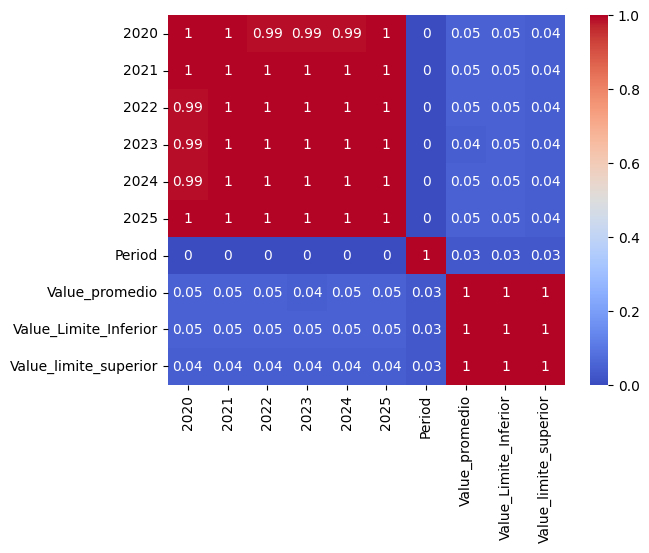

In [36]:
columnas_numericas = df_euramr.select_dtypes(include=["int64", "float64"]).columns
matriz_corr = df_euramr[columnas_numericas].corr().round(2)

sns.heatmap(matriz_corr, annot=True, cmap="coolwarm")